# Heart Attack Prediction with Logistic Regression

## Download the dataset

In [85]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/heart-attack-prediction-dataset")

In [86]:
df = pd.read_csv(path + "/heart_attack_prediction_dataset.csv")

In [87]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [89]:
df.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

## Preliminary Data Preprocessing

In [90]:
# I think we can remove PatientID and Splot the Blood Pressure into Systolic and Diastolic

# Drop PatientID
df = df.drop(columns=['Patient ID'])

# Split Blood Pressure into Systolic and Diastolic
df[["Systolic", "Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True).astype(int)

# Drop Blood Pressure
df = df.drop(columns=["Blood Pressure"])

# Drop Gender

## Encoding the string columns

In [91]:
from sklearn.preprocessing import LabelEncoder

# Store encoders for potential inverse transformation later
string_columns = ["Sex", "Diet", "Alcohol Consumption", "Country", "Continent", "Hemisphere"]
encoders = {}

for column in string_columns:
    encoders[column] = LabelEncoder()
    df[column] = encoders[column].fit_transform(df[column])

## Correlation Analysis

=== CORRELATION MATRIX ===
                                     Age      Sex  Cholesterol  Heart Rate  \
Age                              1.00000  0.02007     -0.00911    -0.00384   
Sex                              0.02007  1.00000      0.00761    -0.01092   
Cholesterol                     -0.00911  0.00761      1.00000     0.00031   
Heart Rate                      -0.00384 -0.01092      0.00031     1.00000   
Diabetes                        -0.01411  0.00358     -0.01343     0.00676   
Family History                   0.00835  0.00218     -0.02161    -0.01347   
Smoking                          0.39489  0.51484      0.01634    -0.01233   
Obesity                         -0.00814  0.00238     -0.01484     0.01272   
Alcohol Consumption             -0.00667  0.00209     -0.00726     0.00346   
Exercise Hours Per Week          0.00121 -0.00698      0.02152     0.00828   
Diet                             0.00210 -0.00805      0.00358    -0.01641   
Previous Heart Problems          0.00

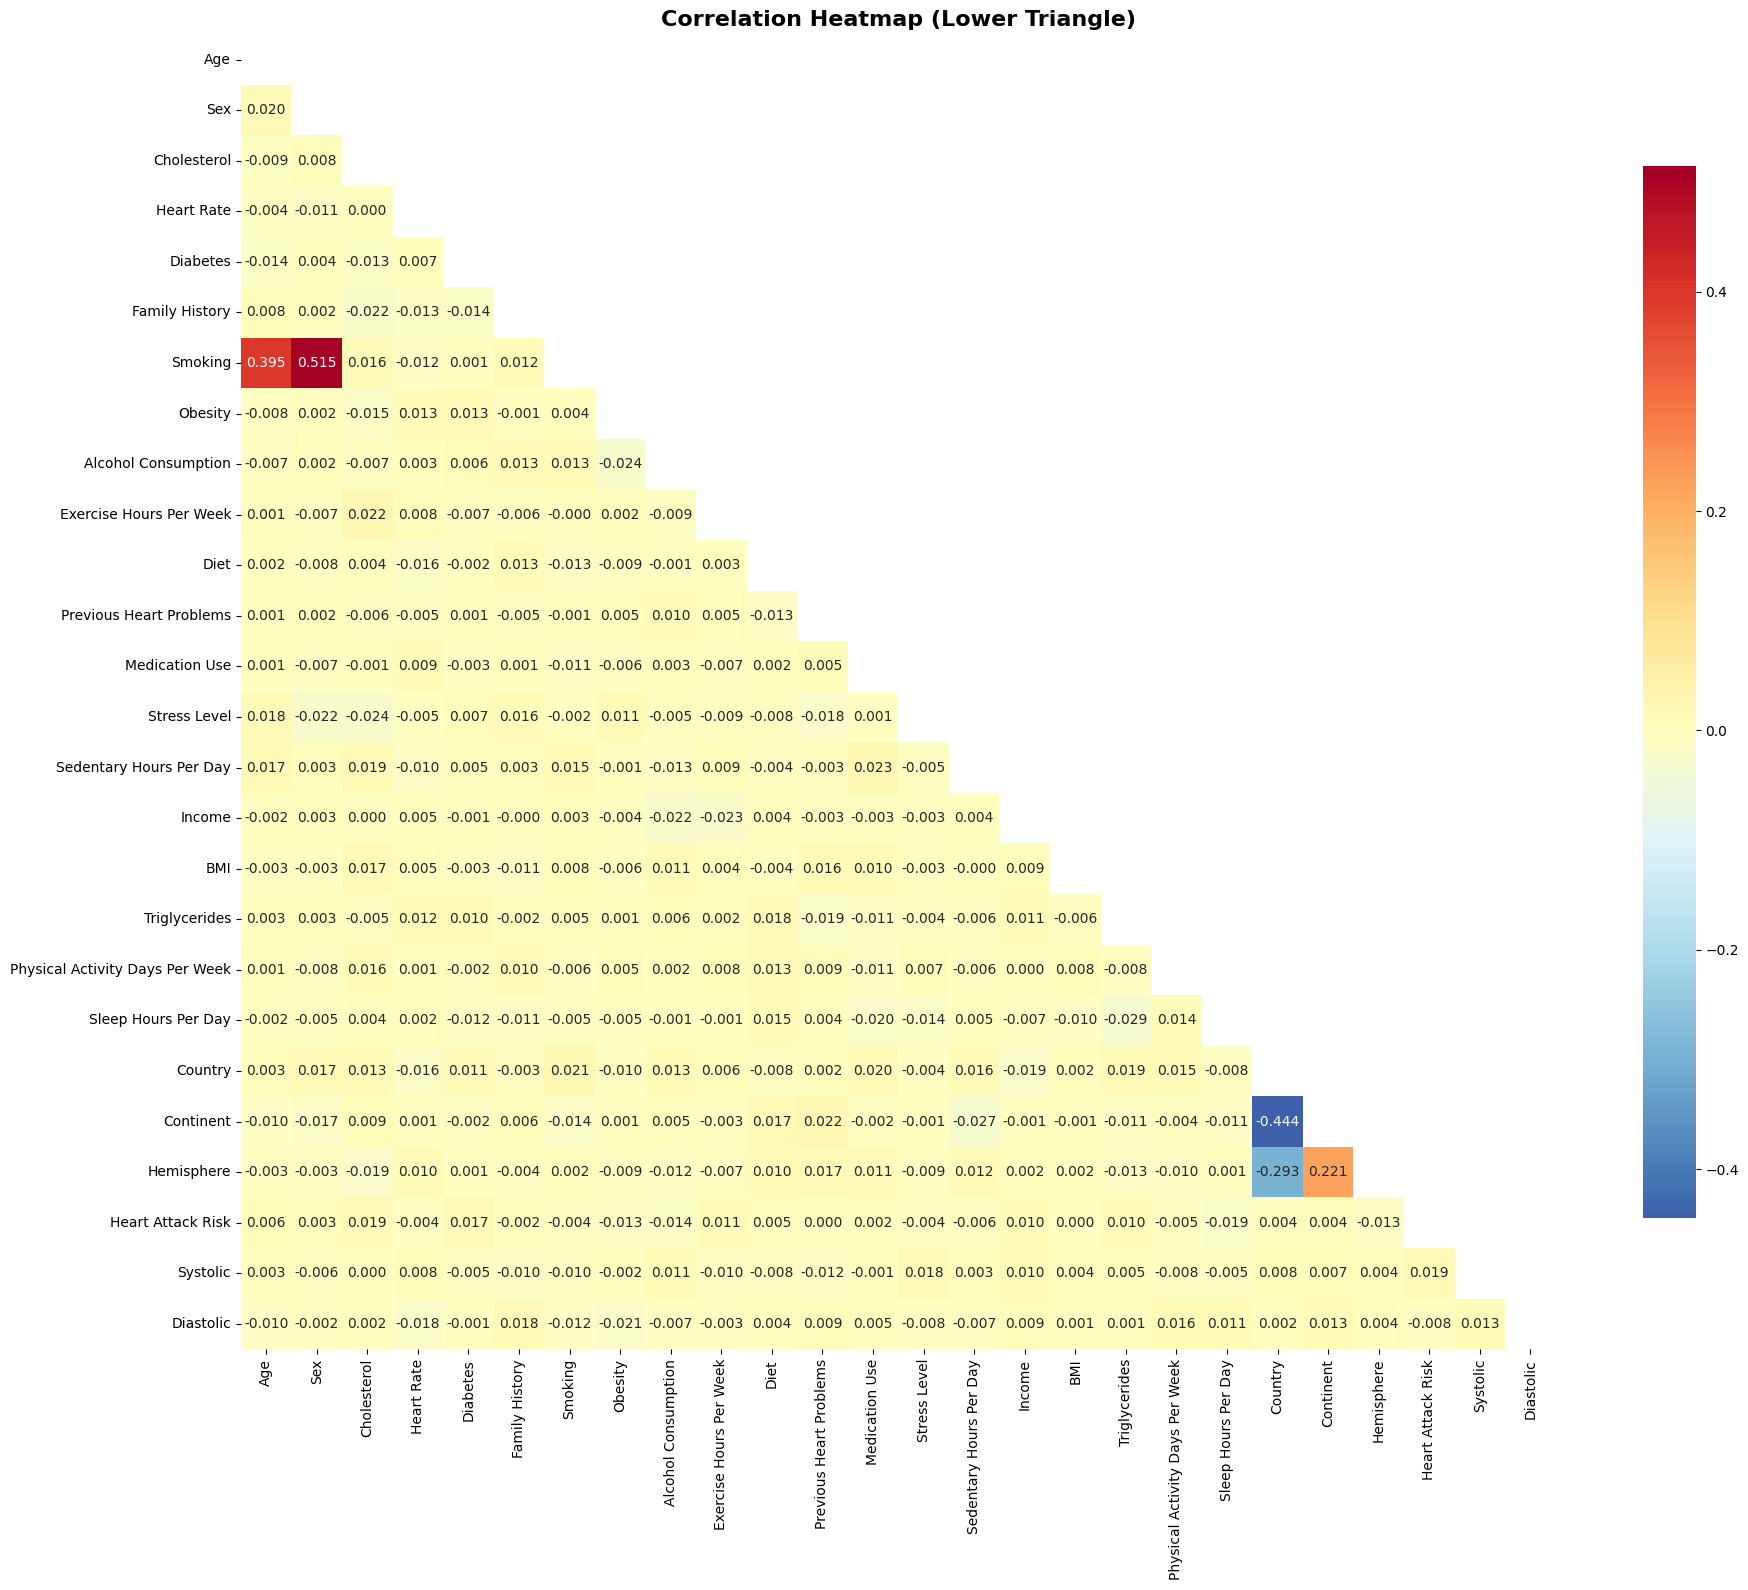

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# 1. BASIC CORRELATION MATRIX
print("=== CORRELATION MATRIX ===")
correlation_matrix = df.corr()
print(correlation_matrix.round(5))


# 2. CORRELATION HEATMAP
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8},
            mask=mask)
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Feature_1': correlation_matrix.columns[i],
            'Feature_2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

In [94]:
encoders['Sex'].inverse_transform([1])

array(['Male'], dtype=object)

In [95]:
# Sort by absolute correlation
corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
top_correlations = corr_df.sort_values('Abs_Correlation', ascending=False).head(15)

print("Top 15 Strongest Correlations:")
print(top_correlations[['Feature_1', 'Feature_2', 'Correlation']].round(3))


Top 15 Strongest Correlations:
                   Feature_1                Feature_2  Correlation
29                       Sex                  Smoking        0.515
310                  Country                Continent       -0.444
5                        Age                  Smoking        0.395
311                  Country               Hemisphere       -0.293
315                Continent               Hemisphere        0.221
290            Triglycerides      Sleep Hours Per Day       -0.029
265  Sedentary Hours Per Day                Continent       -0.027
59               Cholesterol             Stress Level       -0.024
154                  Obesity      Alcohol Consumption       -0.024
194  Exercise Hours Per Week                   Income       -0.023
235           Medication Use  Sedentary Hours Per Day        0.023
178      Alcohol Consumption                   Income       -0.022
36                       Sex             Stress Level       -0.022
51               Cholesterol   

## Preprocessing After Correlation Analysis

In [96]:
# I think we can remove Country/Continent/Hemisphere coz they are not related to the target

df = df.drop(columns=['Country', 'Continent', 'Hemisphere'])


In [97]:
df 

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic,Diastolic
0,67,1,208,72,0,0,1,0,0,4.168189,...,9,6.615001,261404,31.251233,286,0,6,0,158,88
1,21,1,389,98,1,1,1,1,1,1.813242,...,1,4.963459,285768,27.194973,235,1,7,0,165,93
2,21,0,324,72,1,0,0,0,0,2.078353,...,9,9.463426,235282,28.176571,587,4,4,0,174,99
3,84,1,383,73,1,1,1,0,1,9.828130,...,9,7.648981,125640,36.464704,378,3,4,0,163,100
4,66,1,318,93,1,1,1,1,0,5.804299,...,6,1.514821,160555,21.809144,231,1,5,0,91,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,1,121,61,1,1,1,0,1,7.917342,...,8,10.806373,235420,19.655895,67,7,7,0,94,76
8759,28,0,120,73,1,0,0,1,0,16.558426,...,8,3.833038,217881,23.993866,617,4,9,0,157,102
8760,47,1,250,105,0,1,1,1,1,3.148438,...,5,2.375214,36998,35.406146,527,4,4,1,161,75
8761,36,1,178,60,1,0,1,0,0,3.789950,...,5,0.029104,209943,27.294020,114,2,8,0,119,67


## Analyze the distributions of target and features per target value

In [98]:
# Reorder columns with target at the end
df = df[[col for col in df.columns if col != 'Heart Attack Risk'] + ['Heart Attack Risk']]

In [101]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Systolic',
       'Diastolic', 'Heart Attack Risk'],
      dtype='object')

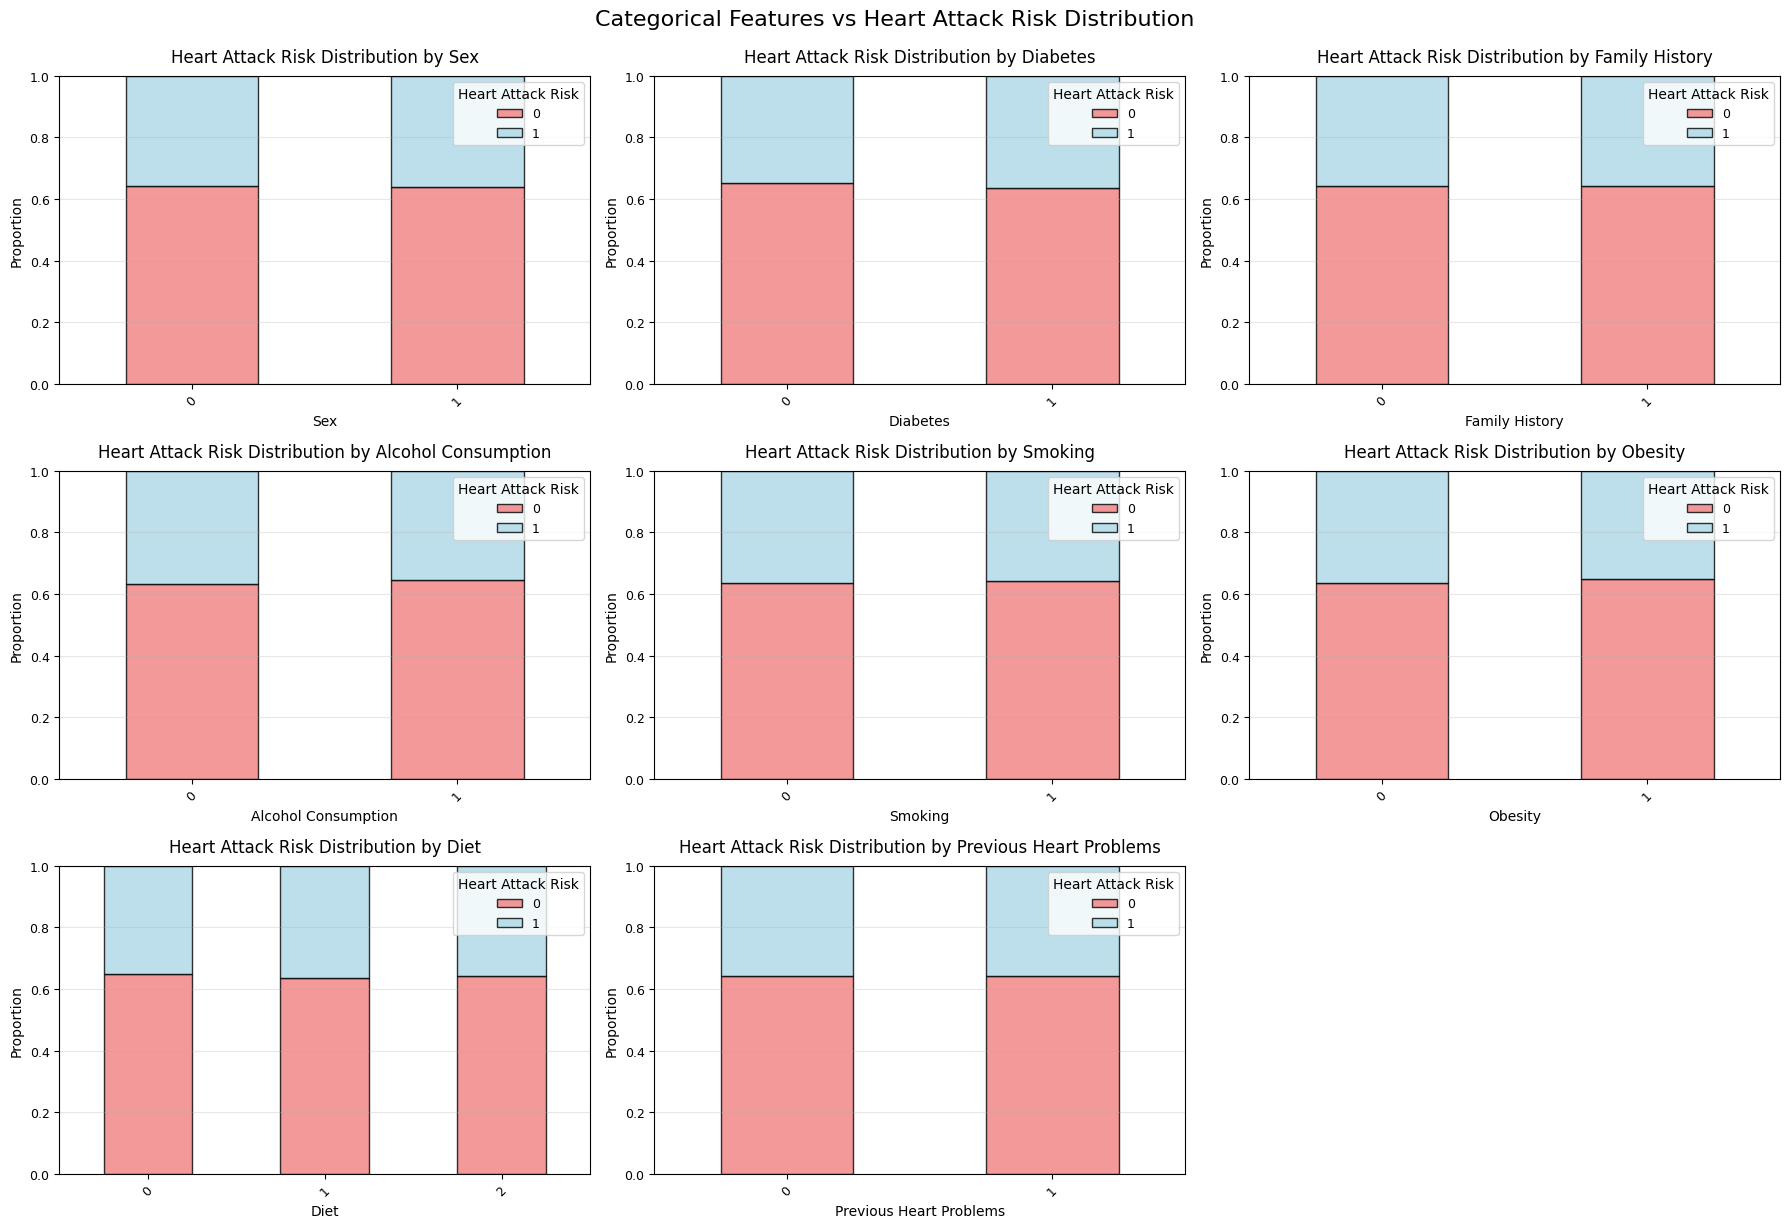

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

categorical_cols = ['Sex', 'Diabetes', 'Family History', 'Alcohol Consumption', 'Smoking', 'Obesity', 'Diet', 'Previous Heart Problems']


def create_distribution_plot(df, cols, target_col):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
    axes = axes.flatten()

    # Define consistent colors for heart attack risk levels
    colors = ['lightcoral', 'lightblue']  # Adjust colors as needed

    for i, col in enumerate(cols):
        # Create crosstab with normalized proportions
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        
        # Create stacked bar chart
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, edgecolor='black', alpha=0.8)
        
        # Customize the subplot
        axes[i].set_title(f'Heart Attack Risk Distribution by {col}', fontsize=12, pad=10)
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Proportion', fontsize=10)
        axes[i].legend(title='Heart Attack Risk', loc='upper right', fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=9)
        axes[i].tick_params(axis='y', labelsize=9)
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].set_ylim(0, 1)  # Ensure y-axis goes from 0 to 1 for proportions

    # Remove unused subplots
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout and add overall title
    plt.tight_layout()
    plt.suptitle('Categorical Features vs Heart Attack Risk Distribution', fontsize=16, y=1.02)
    plt.show()


create_distribution_plot(df, categorical_cols, 'Heart Attack Risk')

In [116]:
import pandas as pd
import scipy.stats

numerical_cols = [col for col in df.columns if col not in ['Heart Attack Risk'] + categorical_cols]


def check_relationship(df, cols, target_col):
    for col in cols:
        ct = pd.crosstab(df[col], df[target_col])
        chi2, p_value = scipy.stats.chi2_contingency(ct)[:2]
        print(f"{col}: Chi-square p-value = {p_value:.4f}")
    print(f"Total p-value = {p_value:.4f}")
check_relationship(df, numerical_cols, 'Heart Attack Risk')

Age: Chi-square p-value = 0.7153
Cholesterol: Chi-square p-value = 0.6656
Heart Rate: Chi-square p-value = 0.7204
Exercise Hours Per Week: Chi-square p-value = 0.4950
Medication Use: Chi-square p-value = 0.8518
Stress Level: Chi-square p-value = 0.8213
Sedentary Hours Per Day: Chi-square p-value = 0.4950
Income: Chi-square p-value = 0.5188
BMI: Chi-square p-value = 0.4950
Triglycerides: Chi-square p-value = 0.5476
Physical Activity Days Per Week: Chi-square p-value = 0.3331
Sleep Hours Per Day: Chi-square p-value = 0.3644
Systolic: Chi-square p-value = 0.4976
Diastolic: Chi-square p-value = 0.5559
Total p-value = 0.5559


=== HEATMAP VISUALIZATION ===

=== Analysis for Sex ===
Contingency Table for Sex vs Heart Attack Risk:
Heart Attack Risk     0     1
Sex                          
0                  1708   944
1                  3916  2195

Chi-square statistic: 0.0705
p-value: 0.7906
Degrees of freedom: 1
Result: No significant relationship (p >= 0.05)
--------------------------------------------------

=== Analysis for Diabetes ===
Contingency Table for Diabetes vs Heart Attack Risk:
Heart Attack Risk     0     1
Diabetes                     
0                  1990  1057
1                  3634  2082

Chi-square statistic: 2.5252
p-value: 0.1120
Degrees of freedom: 1
Result: No significant relationship (p >= 0.05)
--------------------------------------------------

=== Analysis for Family History ===
Contingency Table for Family History vs Heart Attack Risk:
Heart Attack Risk     0     1
Family History               
0                  2848  1595
1                  2776  1544

Chi-square statistic:

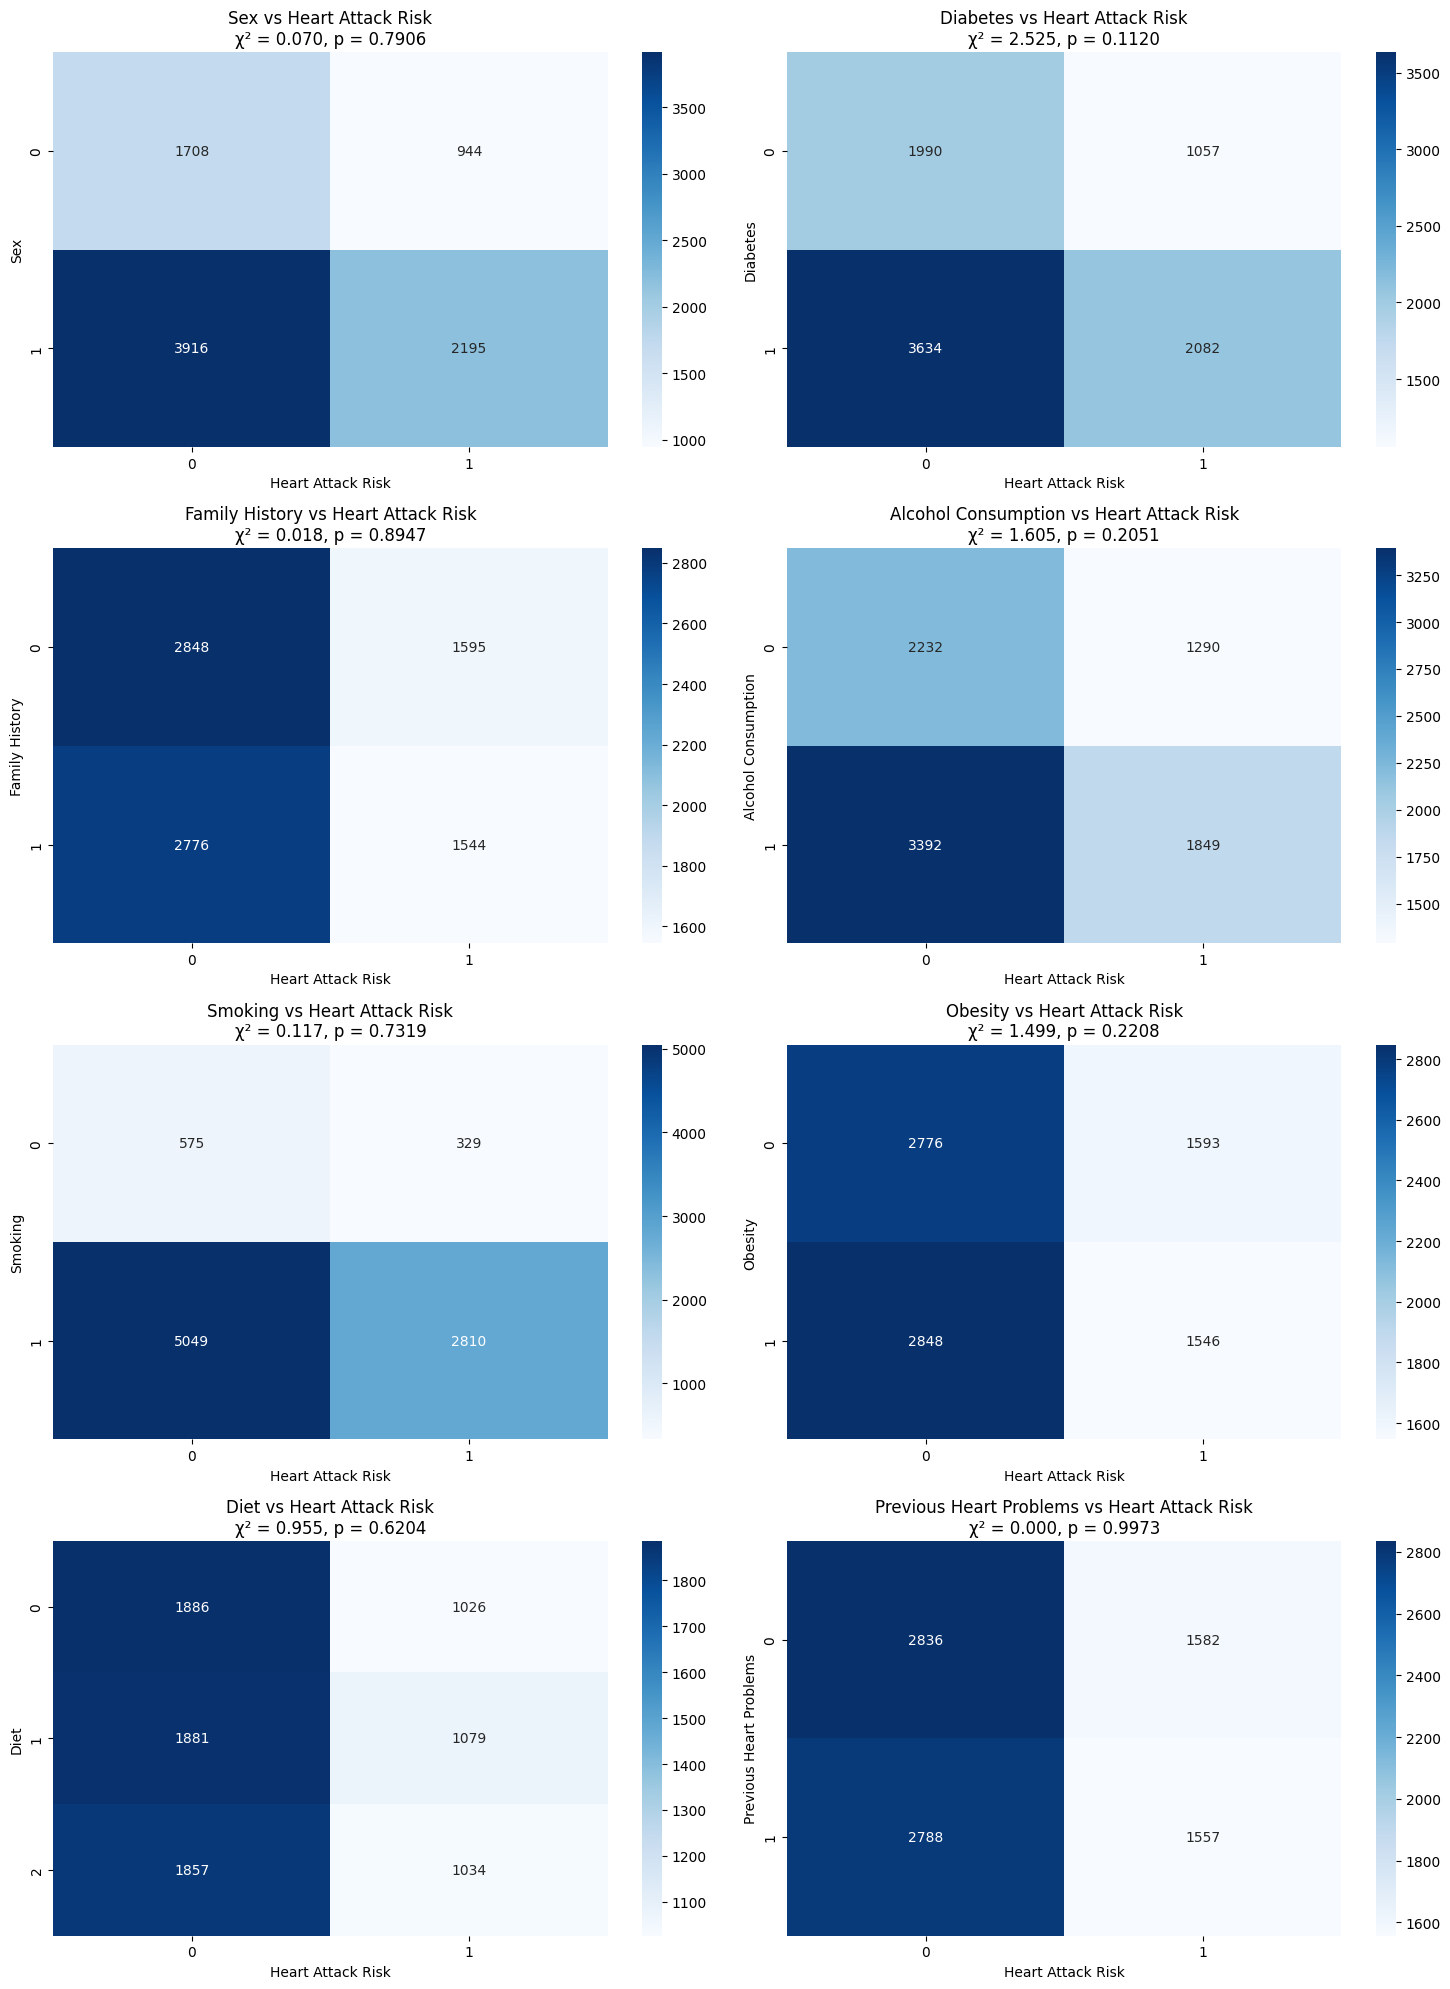


=== DETAILED ANALYSIS ===


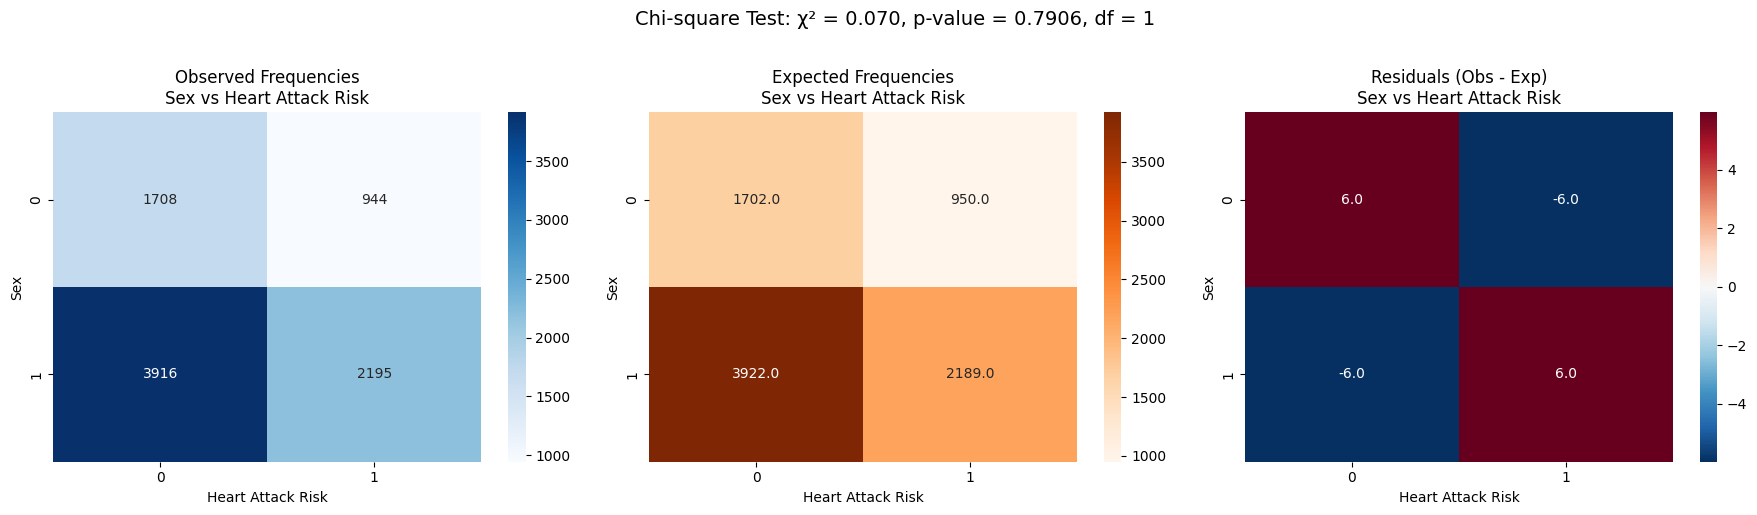


Sex: Chi-square p-value = 0.7906


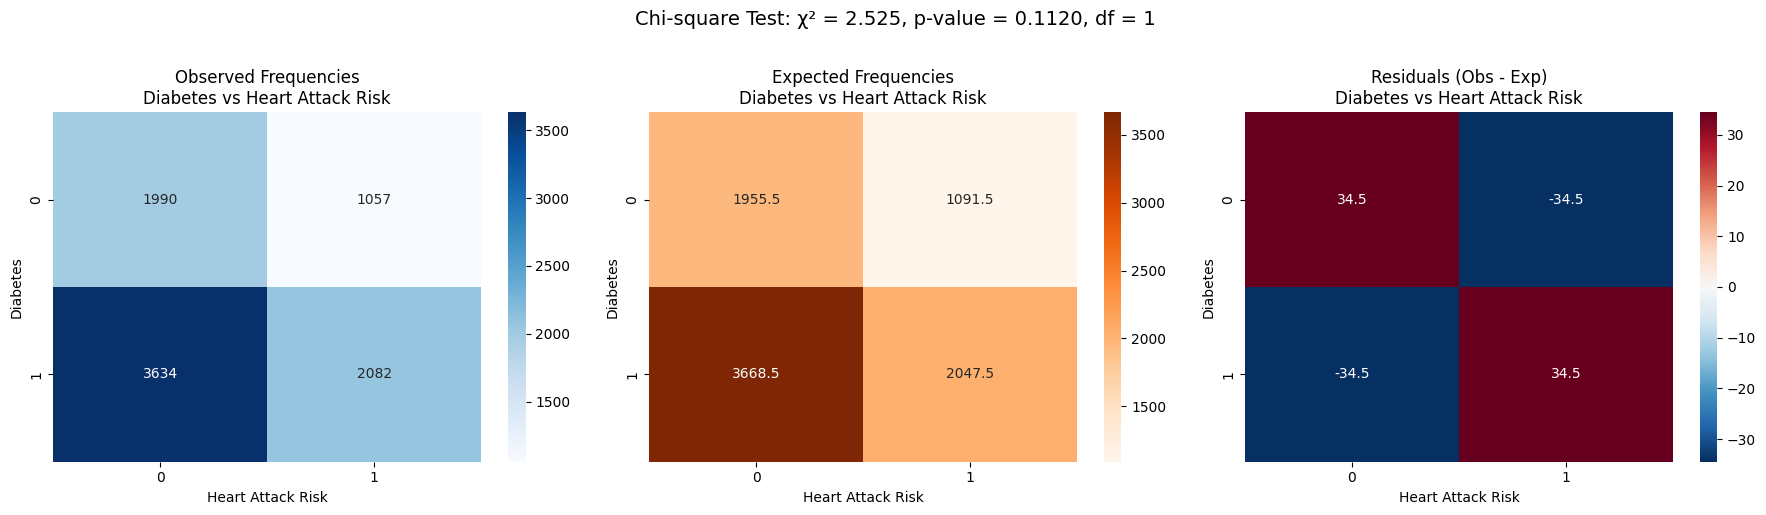


Diabetes: Chi-square p-value = 0.1120


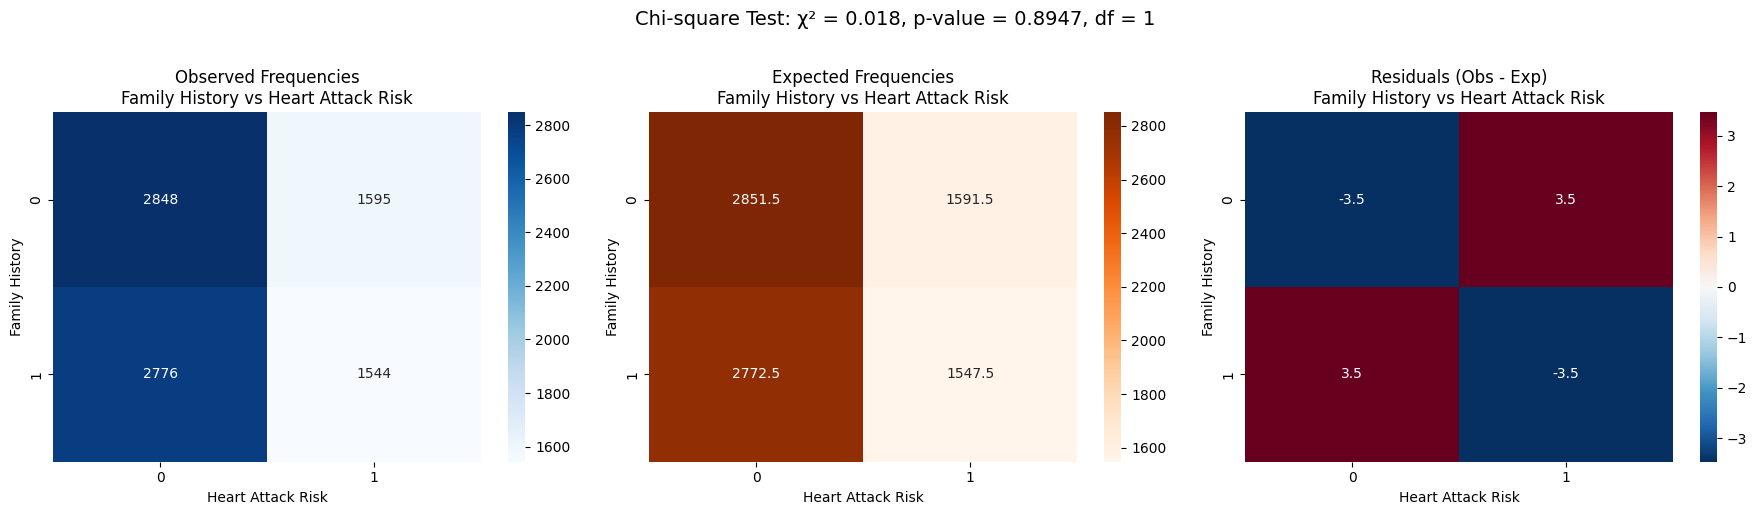


Family History: Chi-square p-value = 0.8947


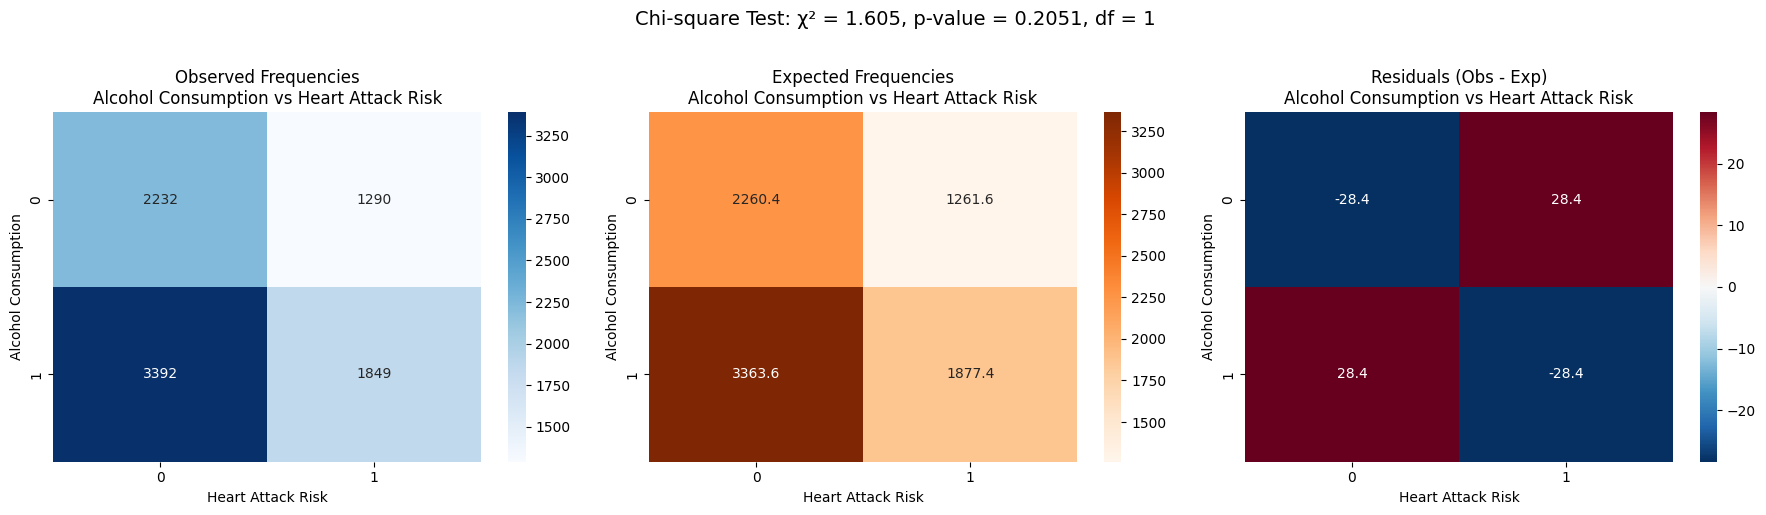


Alcohol Consumption: Chi-square p-value = 0.2051


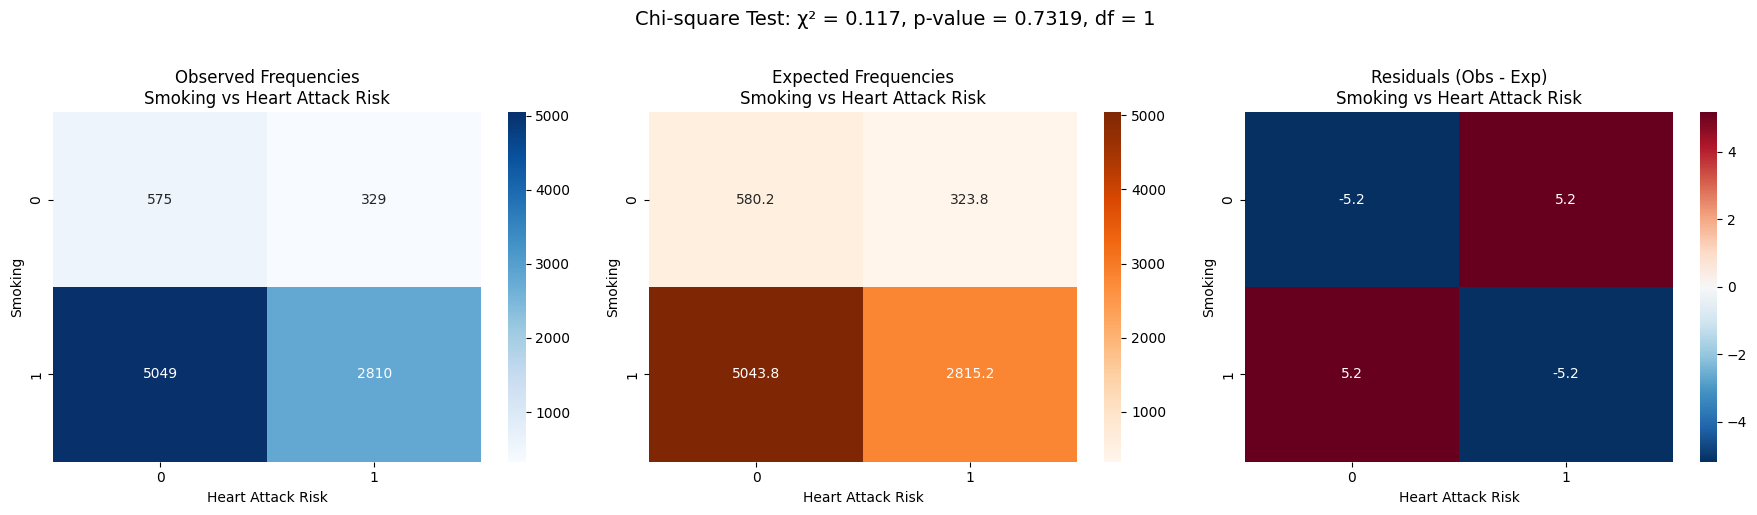


Smoking: Chi-square p-value = 0.7319


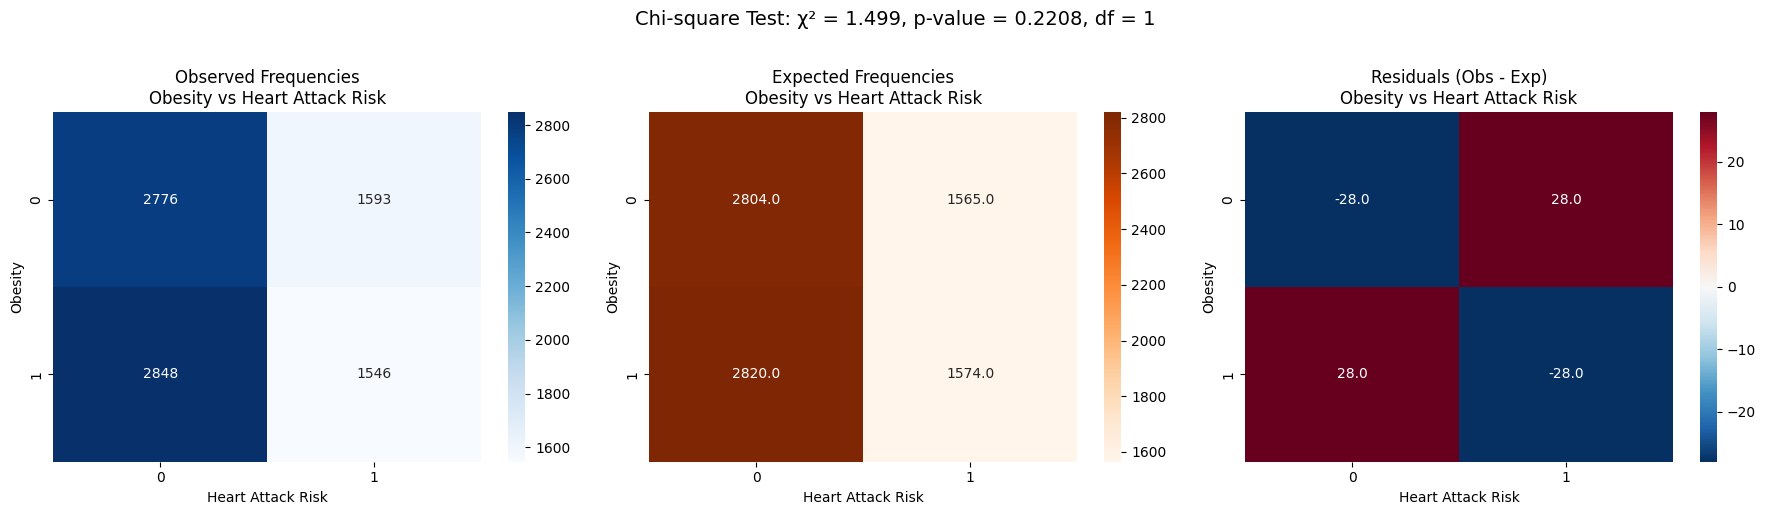


Obesity: Chi-square p-value = 0.2208


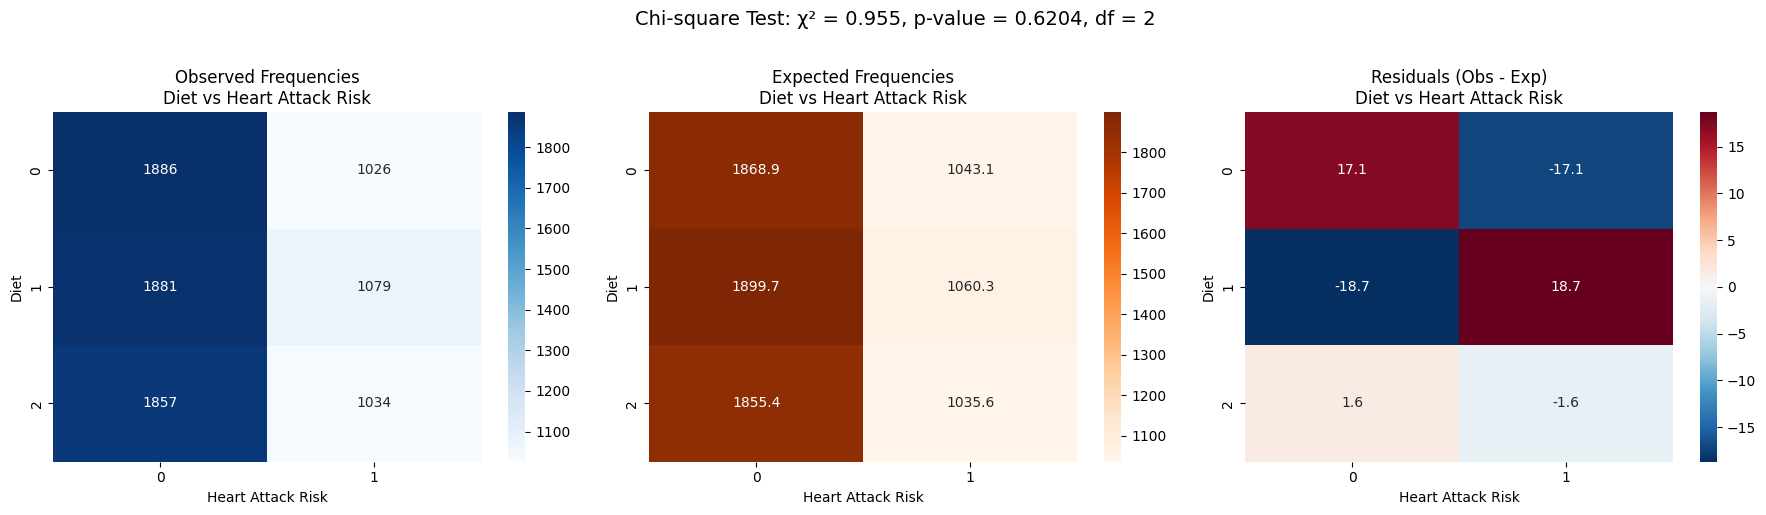


Diet: Chi-square p-value = 0.6204


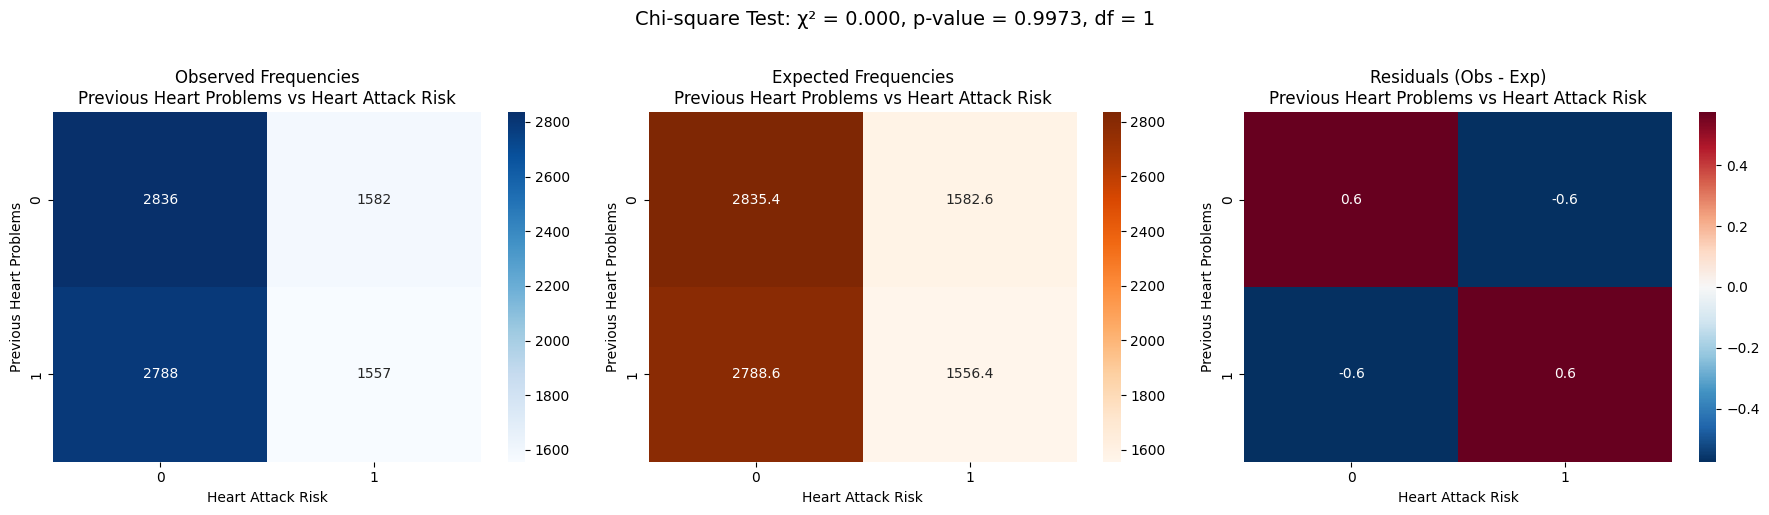


Previous Heart Problems: Chi-square p-value = 0.9973

=== STACKED BAR CHARTS ===


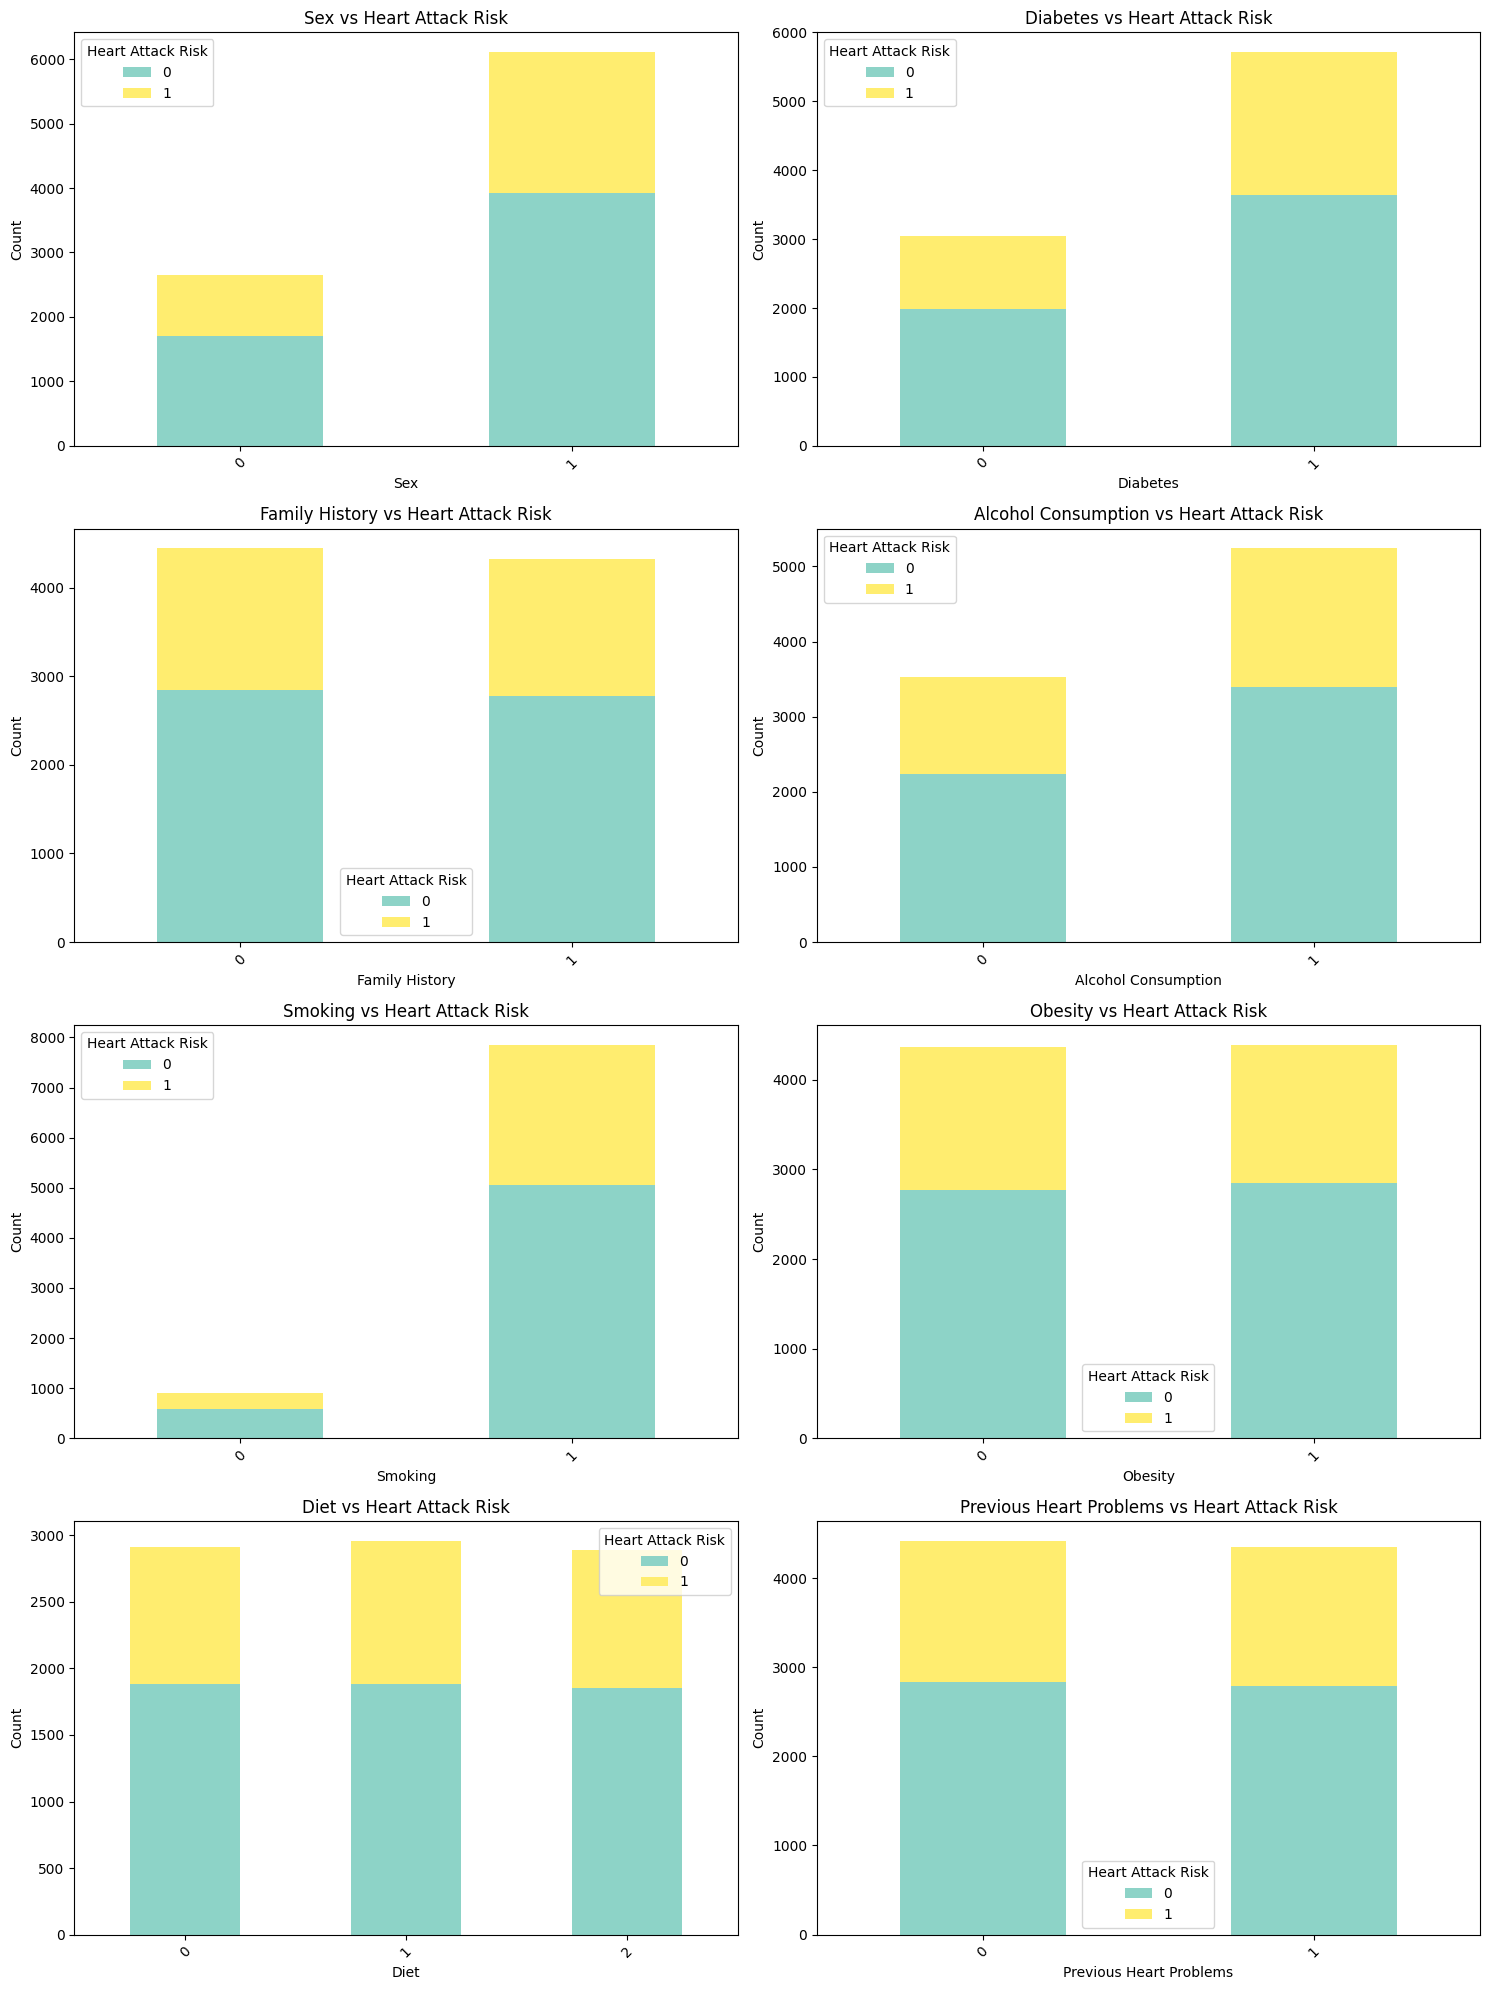

In [118]:
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming categorical_cols is defined elsewhere in your code
# categorical_cols = ['column1', 'column2', ...]  # Define your categorical columns

# Get numerical columns (excluding target and categorical columns)
numerical_cols = [col for col in df.columns if col not in ['Heart Attack Risk'] + categorical_cols]

def check_relationship(df, cols, target_col):
    """
    Check relationship between columns and target using chi-square test
    and visualize contingency tables
    """
    n_cols = len(cols)
    n_rows = (n_cols + 1) // 2  # 2 plots per row
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(cols):
        row = i // 2
        col_idx = i % 2
        ax = axes[row, col_idx]
        
        print(f"\n=== Analysis for {col} ===")
        
        # Create contingency table
        ct = pd.crosstab(df[col], df[target_col])
        
        # Display the contingency table
        print(f"Contingency Table for {col} vs {target_col}:")
        print(ct)
        print()
        
        # Perform chi-square test
        chi2, p_value, dof, expected = scipy.stats.chi2_contingency(ct)
        
        # Display test results
        print(f"Chi-square statistic: {chi2:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Degrees of freedom: {dof}")
        
        # Create heatmap of contingency table
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'{col} vs {target_col}\nχ² = {chi2:.3f}, p = {p_value:.4f}')
        ax.set_xlabel(target_col)
        ax.set_ylabel(col)
        
        # Interpretation
        alpha = 0.05
        if p_value < alpha:
            print(f"Result: Significant relationship (p < {alpha})")
        else:
            print(f"Result: No significant relationship (p >= {alpha})")
        
        print("-" * 50)
    
    # Remove empty subplots if odd number of variables
    if n_cols % 2 == 1:
        axes[-1, -1].remove()
    
    plt.tight_layout()
    plt.show()

def plot_contingency_detailed(df, cols, target_col):
    """
    Create detailed contingency table plots with observed vs expected frequencies
    """
    for col in cols:
        # Create contingency table
        ct = pd.crosstab(df[col], df[target_col])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = scipy.stats.chi2_contingency(ct)
        
        # Create expected frequencies DataFrame
        expected_df = pd.DataFrame(expected, 
                                 index=ct.index, 
                                 columns=ct.columns)
        
        # Create subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Observed frequencies
        sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Observed Frequencies\n{col} vs {target_col}')
        axes[0].set_xlabel(target_col)
        axes[0].set_ylabel(col)
        
        # Plot 2: Expected frequencies
        sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
        axes[1].set_title(f'Expected Frequencies\n{col} vs {target_col}')
        axes[1].set_xlabel(target_col)
        axes[1].set_ylabel(col)
        
        # Plot 3: Residuals (Observed - Expected)
        residuals = ct - expected_df
        sns.heatmap(residuals, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[2])
        axes[2].set_title(f'Residuals (Obs - Exp)\n{col} vs {target_col}')
        axes[2].set_xlabel(target_col)
        axes[2].set_ylabel(col)
        
        # Add statistics to the plot
        fig.suptitle(f'Chi-square Test: χ² = {chi2:.3f}, p-value = {p_value:.4f}, df = {dof}', 
                    fontsize=14, y=1.02)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n{col}: Chi-square p-value = {p_value:.4f}")

def plot_stacked_bars(df, cols, target_col):
    """
    Create stacked bar charts for contingency tables
    """
    n_cols = len(cols)
    n_rows = (n_cols + 1) // 2
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(cols):
        row = i // 2
        col_idx = i % 2
        ax = axes[row, col_idx]
        
        # Create contingency table
        ct = pd.crosstab(df[col], df[target_col])
        
        # Create stacked bar chart
        ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
        ax.set_title(f'{col} vs {target_col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.legend(title=target_col)
        ax.tick_params(axis='x', rotation=45)
    
    # Remove empty subplots if odd number of variables
    if n_cols % 2 == 1:
        axes[-1, -1].remove()
    
    plt.tight_layout()
    plt.show()

# Run the analysis with different visualization options

# Option 1: Simple heatmap visualization
print("=== HEATMAP VISUALIZATION ===")
check_relationship(df, categorical_cols, 'Heart Attack Risk')

# Option 2: Detailed analysis with observed vs expected frequencies
print("\n=== DETAILED ANALYSIS ===")
plot_contingency_detailed(df, categorical_cols, 'Heart Attack Risk')

# Option 3: Stacked bar charts
print("\n=== STACKED BAR CHARTS ===")
plot_stacked_bars(df, categorical_cols, 'Heart Attack Risk')

## Split the data into training and testing sets

In [138]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop("Heart Attack Risk", axis=1)
y = df["Heart Attack Risk"]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [139]:
# Check the class balance
print("Training set target distribution:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTest set target distribution:")
print(y_test.value_counts(normalize=True).round(2))

Training set target distribution:
Heart Attack Risk
0    0.64
1    0.36
Name: proportion, dtype: float64

Test set target distribution:
Heart Attack Risk
0    0.64
1    0.36
Name: proportion, dtype: float64


In [146]:
from sklearn.linear_model import LogisticRegression

# Initialize the logistic regression model using sklearn
model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

# Since sklearn's LogisticRegression does not provide cost history, we will not plot it


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [155]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score

# Define a threshold for classification
threshold = 0.5

# Make predictions on the test set using the threshold
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= threshold).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Calculate precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.3f}")

# Calculate recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.2f}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2f}")

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {roc_auc:.2f}")


Accuracy: 0.49
Precision: 0.348
Recall: 0.48
F1 Score: 0.40
Confusion Matrix:
[[559 566]
 [326 302]]
ROC AUC: 0.49


Converged after 3 iterations
Training completed after 3 iterations
Final cost: 12.371878


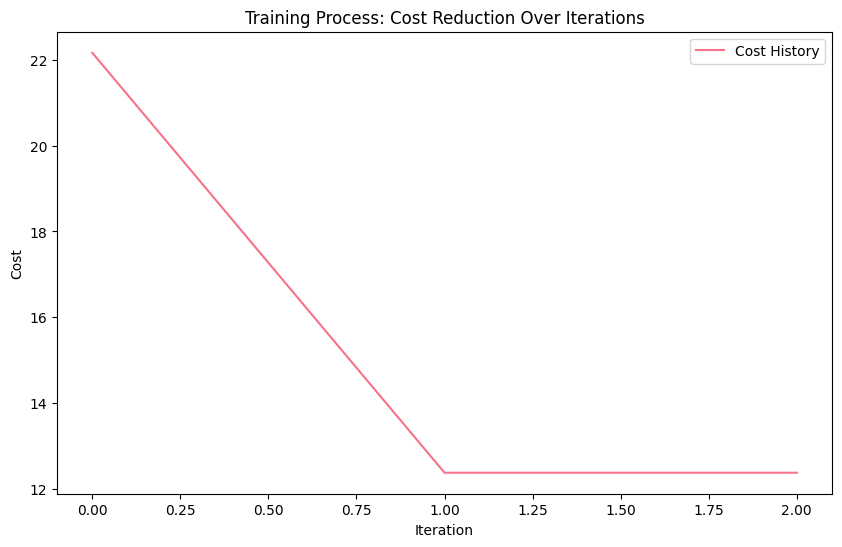

Custom Model Accuracy: 0.36
Custom Model Precision: 0.358
Custom Model Recall: 1.00
Custom Model F1 Score: 0.53
Custom Model ROC AUC: 0.50


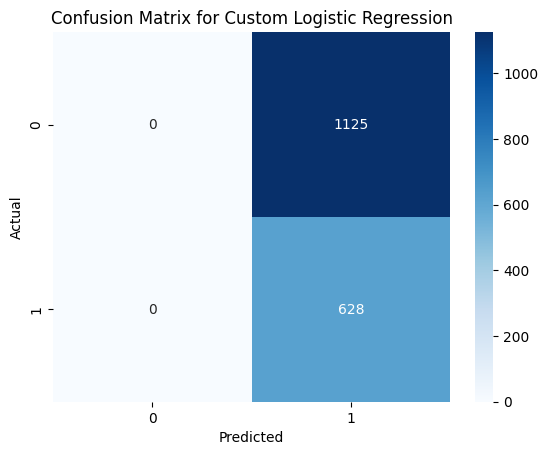

In [164]:
# Use the custom Logistic Regression from scratch
from logistic_regression_from_scratch import LogisticRegressionFromScratch

# Initialize the custom logistic regression model
custom_model = LogisticRegressionFromScratch(learning_rate=0.001, max_iterations=1000)

# Add intercept to the training and test data
X_train_with_intercept = custom_model._add_intercept(X_train)
X_test_with_intercept = custom_model._add_intercept(X_test)

# Train the custom model
custom_model.fit(X_train_with_intercept, y_train)

# Plot the cost history to show the training process
plt.figure(figsize=(10, 6))
plt.plot(custom_model.cost_history, label='Cost History')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Process: Cost Reduction Over Iterations')
plt.legend()
plt.show()

# Make predictions on the test set
y_pred_proba_custom = custom_model.predict_proba(X_test_with_intercept)
y_pred_custom = (y_pred_proba_custom >= threshold).astype(int)

# Calculate and print metrics
accuracy_custom = accuracy_score(y_test, y_pred_custom)
precision_custom = precision_score(y_test, y_pred_custom)
recall_custom = recall_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)
roc_auc_custom = roc_auc_score(y_test, y_pred_proba_custom)

print(f"Custom Model Accuracy: {accuracy_custom:.2f}")
print(f"Custom Model Precision: {precision_custom:.3f}")
print(f"Custom Model Recall: {recall_custom:.2f}")
print(f"Custom Model F1 Score: {f1_custom:.2f}")
print(f"Custom Model ROC AUC: {roc_auc_custom:.2f}")

# Plot confusion matrix
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(conf_matrix_custom, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Custom Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [169]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for different solvers
param_grid = {
    'solver': ['lbfgs', 'sag', 'saga', 'newton-cg', 'liblinear'],
    'max_iter': [1000],  # Ensure enough iterations for convergence
    'class_weight': ['balanced']
}

# Initialize the logistic regression model
logistic_regression = LogisticRegression(random_state=42)

# Set up the grid search with cross-validation
grid_search = GridSearchCV(
    estimator=logistic_regression,
    param_grid=param_grid,
    scoring='f1',
    cv=10,  # 5-fold cross-validation
    n_jobs=-1  # Use all available cores
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Solver: {best_params['solver']}")
print(f"Best Cross-Validated F1 Score: {best_score:.4f}")

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Set F1 Score with Best Solver: {accuracy_best:.4f}")


Best Solver: saga
Best Cross-Validated F1 Score: 0.4772
Test Set F1 Score with Best Solver: 0.3885
